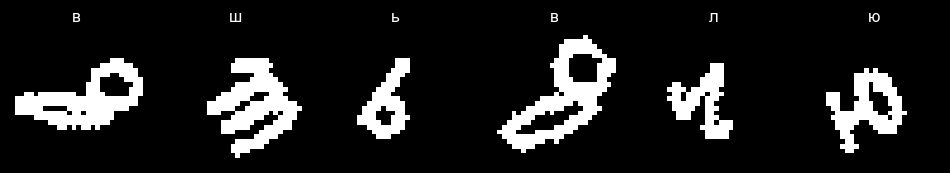

In [1]:
import sys, os, json, torch, math
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../..'))
from DL.models import CustomClassifierFromConfig, RotateNet, CascadeNet
from DL.historical_trash.trainer import ModelTrainer
from DL.historical_trash.visualize import plot_confusion_matrices, visualize_overlay_gradcam
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RotatedCyrillicDataset(Dataset):
    """Датасет генерирует символы и жестко вращает их в пределах [-150, 150] градусов"""
    def __init__(self, num_samples, seed, max_angle=150):
        self.num_samples = num_samples
        self.generator = LowerCaseLettersGenerator(seed=seed)
        self.char_to_idx = {char: idx for idx, char in enumerate(self.generator.ALLOWS_SYMBOLS)}
        self.idx_to_char = {idx: char for char, idx in self.char_to_idx.items()}
        self.max_angle = max_angle
        self.rng = torch.Generator().manual_seed(seed)

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        img_np, label_char = self.generator.generate()
        img_tensor = torch.from_numpy(img_np).float().unsqueeze(0) / 255.0

        # Рандомный угол
        angle = torch.empty(1).uniform_(-self.max_angle, self.max_angle, generator=self.rng).item()

        # Вращение
        img_rotated = TF.rotate(img_tensor, angle)

        # Истинные sin и cos (Target для RotateNet)
        angle_rad = math.radians(angle)
        sin_cos_target = torch.tensor([math.sin(angle_rad), math.cos(angle_rad)], dtype=torch.float32)

        return img_rotated, self.char_to_idx[label_char], sin_cos_target

train_dataset = RotatedCyrillicDataset(60000, 42, max_angle=150)
test_dataset = RotatedCyrillicDataset(15000, 999, max_angle=150)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Визуализация датасета
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    img, lbl, sincos = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(train_dataset.idx_to_char[lbl])
    axes[i].axis('off')
plt.show()

In [2]:
print("=== ЭТАП 1: Обучение RotateNet ===")
rotatenet = RotateNet().to(device)
opt_rot = torch.optim.Adam(rotatenet.parameters(), lr=1e-3)
mse_loss = nn.MSELoss()

# Короткий цикл специально для регрессии углов
epochs_rot = 5
for epoch in range(epochs_rot):
    rotatenet.train()
    running_loss = 0.0
    for img, _, sin_cos_target in train_loader:
        img, target = img.to(device), sin_cos_target.to(device)

        opt_rot.zero_grad()
        pred_sin_cos, _ = rotatenet(img)

        # Лосс (MSE + Penalty из статьи)
        loss = mse_loss(pred_sin_cos, target)
        loss.backward()
        opt_rot.step()

        running_loss += loss.item() * img.size(0)
    print(f"Epoch {epoch+1}/{epochs_rot} | MSE Loss: {running_loss / len(train_dataset):.4f}")

print("RotateNet успешно обучен выравнивать геометрию!")

=== ЭТАП 1: Обучение RotateNet ===
Epoch 1/5 | MSE Loss: 0.4274
Epoch 2/5 | MSE Loss: 0.2209
Epoch 3/5 | MSE Loss: 0.1324
Epoch 4/5 | MSE Loss: 0.1043
Epoch 5/5 | MSE Loss: 0.1029
RotateNet успешно обучен выравнивать геометрию!


In [3]:
print("\n=== ЭТАП 2: Обучение 8KB CascadeNet (LeNet + RotateNet Features) ===")

with open('../configs/lenet/lenet_8kb.json', 'r') as f:
    config_8kb = json.load(f)
config_8kb['num_classes'] = len(train_dataset.char_to_idx)

# Собираем Каскад
cascade_model = CascadeNet(config_8kb, rotatenet).to(device)
optimizer_cascade = torch.optim.Adam(cascade_model.classifier.parameters(), lr=1e-3)

# Тренируем каскад (RotateNet внутри заморожен)
trainer_cascade = ModelTrainer(
    cascade_model,
    optimizer_cascade,
    nn.CrossEntropyLoss(),
    device,
    use_background_loss=True,
    bg_loss_alpha=15.0,
    bg_loss_n=2
)

hist_cascade = trainer_cascade.fit(train_loader, test_loader, epochs=15)

# Визуализации
print("\nМатрица ошибок Каскада:")
plot_confusion_matrices(cascade_model, cascade_model, test_loader, test_dataset, device)

print("\nGrad-CAM: На что смотрит LeNet после выравнивания и слияния фичей:")
visualize_overlay_gradcam(cascade_model, test_dataset, device, "CascadeNet Grad-CAM")


=== ЭТАП 2: Обучение 8KB CascadeNet (LeNet + RotateNet Features) ===
Epoch 1/15


Train Loss: 0.7687 | Train Acc: 0.8708 | BG Loss: 0.0086
Val Loss: 0.2251 | Val Acc: 0.9734

Epoch 2/15


Train Loss: 0.1533 | Train Acc: 0.9831 | BG Loss: 0.0000
Val Loss: 0.1065 | Val Acc: 0.9885

Epoch 3/15


Train Loss: 0.0848 | Train Acc: 0.9911 | BG Loss: 0.0000
Val Loss: 0.0710 | Val Acc: 0.9911

Epoch 4/15


Train Loss: 0.0581 | Train Acc: 0.9931 | BG Loss: 0.0000
Val Loss: 0.0506 | Val Acc: 0.9935

Epoch 5/15


...

Train Loss: 0.0172 | Train Acc: 0.9972 | BG Loss: 0.0000
Val Loss: 0.0182 | Val Acc: 0.9967

Epoch 13/15


Train Loss: 0.0159 | Train Acc: 0.9971 | BG Loss: 0.0000
Val Loss: 0.0128 | Val Acc: 0.9981

Epoch 14/15


Train Loss: 0.0153 | Train Acc: 0.9971 | BG Loss: 0.0000
Val Loss: 0.0156 | Val Acc: 0.9967

Epoch 15/15


Train Loss: 0.0154 | Train Acc: 0.9970 | BG Loss: 0.0000
Val Loss: 0.0117 | Val Acc: 0.9981


Матрица ошибок Каскада:


ValueError: too many values to unpack (expected 2)